Intercept: -9.9710051410409
Coefficient: 0.3596347877191965
Probability of passing for 33 hours: 0.8695451255816024
Minimum hours for >95% probability: 36.0


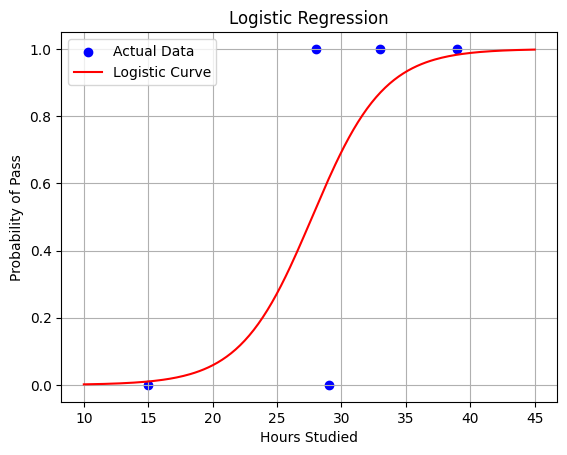

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Dataset
X = np.array([29, 15, 33, 28, 39]).reshape(-1, 1)
y = np.array([0, 0, 1, 1, 1])   # 0 = Fail, 1 = Pass

# Create and train model
model = LogisticRegression()
model.fit(X, y)

# Get learned parameters
intercept = model.intercept_[0]
coef = model.coef_[0][0]

print("Intercept:", intercept)
print("Coefficient:", coef)

# 1️⃣ Probability for 33 hours
prob_33 = model.predict_proba([[33]])[0][1]
print("Probability of passing for 33 hours:", prob_33)

# 2️⃣ Minimum hours for probability > 95%
target_prob = 0.95
z_required = np.log(target_prob / (1 - target_prob))

# Solve z = intercept + coef * hours
hours_required = (z_required - intercept) / coef
print("Minimum hours for >95% probability:", np.ceil(hours_required))

# ---- Plot sigmoid curve ----
x_values = np.linspace(10, 45, 200).reshape(-1, 1)
y_values = model.predict_proba(x_values)[:, 1]

plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(x_values, y_values, color='red', label='Logistic Curve')

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()
